In [2]:
from os import rename

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
import importlib
import config
importlib.reload(config)
import pandas_market_calendars as mcal
sys.path.insert(0, '../scripts')
from scripts.remove_non_trading_days import remove_non_trading_days

from config import BB_PRICES_COMPLETE, SENT_TIMESTAMP_CLEANED,US_TICKERS_FINAL_adj, DAILY_SENTIMENT

In [3]:
#open sentiment row and trading day file
#Note pdf = price dataframe
pdf = pd.read_parquet(BB_PRICES_COMPLETE)
ust = pd.read_csv(US_TICKERS_FINAL_adj)
sdf = pd.read_parquet(SENT_TIMESTAMP_CLEANED)

In [4]:
ust.dtypes

ISIN              object
Ticker            object
start_date_s      object
end_date_s        object
start_date_px     object
end_date_px       object
Sector            object
bb_tcm            object
alt_bb_tcm        object
mkt_cap          float64
turnover         float64
bb_tcm_note       object
bb_start_date     object
bb_end_date       object
dtype: object

In [6]:
#Ensure price dataframe only has valid trading days by running it against the pandas_market_calendars.
pdf = remove_non_trading_days(pdf,'date')

# get the NYSE calendar
nyse = mcal.get_calendar('NYSE')

print(f'Number of unique stocks in pdf: {len(pdf['ISIN'].unique())}')
print(pdf.dtypes)

There are currently 1921 days in your df
There are 1921 days in the NYSE schedule
Therefore we remove 0 days from the df
df shape after cleaning:(2408260, 5)
Number of unique stocks in pdf: 1469
ISIN                       object
Ticker                     object
resolved_ticker            object
date               datetime64[ns]
px_last                   float64
dtype: object


In [11]:
print(len(pdf_clean['date'].unique()))
print(len(sdf['Timestamp'].dt.date.unique()))
#Note a difference of approx 40 days is fine as you pulled 20 days prior and 20 days post the testing period.

1921
1884


In [13]:
#create daily aggregation dataframe - this will be the empty shell we intend to fill
#LOOK AT THE CELL ABOVE - DO YOU NEED TO USE pdf or pdf_clean? Make sure you know and then proceed.

#Note ddf = daily dataframe
#ddf = pdf[['ISIN', 'date']].drop_duplicates().reset_index(drop=True)
#OR
ddf = pdf_clean[['ISIN', 'date']].drop_duplicates().reset_index(drop=True)

print(f'Number of duplicated pairs: {ddf.duplicated(subset=['ISIN','date']).sum()}')
print(ddf.shape)

Number of duplicated pairs: 0
(2433754, 2)


In [14]:
ddf.rename(columns={'date':'trading_day'}, inplace=True)

In [15]:
#Merge the sector from ust into the pdf based on ISIN
ddf2 = ddf.merge(ust[['ISIN','Sector']], on='ISIN', how='left')
print(f'lenght of ddf: {len(ddf)}')
print(f'lenght of ddf2: {len(ddf)}')
print(ddf2['Sector'].value_counts())
print(ddf2['Sector'].isnull().sum())

lenght of ddf: 2433754
lenght of ddf2: 2433754
Sector
Financials                477748
Consumer Discretionary    432933
Industrials               403347
Information Technology    315644
Health Care               245347
Consumer Staples          132759
Materials                 124431
Utilities                 110199
Energy                    103393
Real Estate                54487
Communication Services     33466
Name: count, dtype: int64
0


In [16]:
sdf.rename(columns={'Isin':'ISIN'}, inplace=True)
sdf.columns

Index(['StoryID', 'Timestamp_utc', 'Ticker', 'Country', 'ISIN', 'Sentiment',
       'Confidence', 'Novelty', 'Topic', 'Relevance', 'HeadlineOnly',
       'AutoMessage', 'Source', 'MarketImpactScore', 'Prob_POS', 'Prob_NTR',
       'Prob_NEG', 'Timestamp'],
      dtype='object')

In [17]:
"""
Aggregates raw sentiment stories down to one row per
(ISIN, trading_day), then attaches sector-relative leave-one-out z-scores and
merges the result onto the trading-day skeleton.

Input dataframes
    sdf  - raw sentiment dataframe
    ddf2 - empty dataframe: ISIN, trading_day, Sector

Output dataframe and new measures.
    sentiment_daily.parquet - one row per (ISIN, trading_day, Sector) with:
        sentiment_score     relevance x confidence weighted mean sentiment
        sentiment_volume    log1p(count of new stories, Novelty == 1)
        sentiment_score_z   leave-one-out z-score vs covered sector peers
        sentiment_volume_z  leave-one-out z-score vs covered sector peers
        story_count
"""
#Define some variables:
MIN_GROUP_SIZE = 4  # stock itself + at least 3 peers with news that day
STD_FLOOR = 1e-6 #prevents floating-point ghost variance
Z_CAP = 5 #winsorisation bound

# 1. Load inputs if not already loaded
if 'sdf' in globals() and sdf is not None:
    print(f'sdf already loaded in the shape of: {sdf.shape}')
else:
    print(f'sdf note found. Loading file now: {SENT_TIMESTAMP_CLEANED}')
    sdf = pd.read_parquet(SENT_TIMESTAMP_CLEANED)
    sdf.rename(columns={'Isin':'ISIN'}, inplace=True)

#Remove the time-zone awareness and set all times to midnight.
sdf['trading_day'] = sdf['Timestamp'].dt.normalize().dt.tz_localize(None)

# 2. Story-level preparation
sdf['weight'] = sdf['Relevance'] * sdf['Confidence']
sdf['weighted_sentiment'] = sdf['weight'] * sdf['Sentiment']
sdf['is_new_story'] = (sdf['Novelty'] == 1).astype('int8')

# 3. Aggregate to one row per (Isin, trading_day)
agg = (
    sdf.groupby(['ISIN', 'trading_day'], sort=False)
       .agg(
            weighted_sentiment_sum=('weighted_sentiment', 'sum'),
            weight_sum=('weight', 'sum'),
            new_story_count=('is_new_story', 'sum'),
            story_count=('Sentiment','size'),
       )
       .reset_index()
)

# Weighted mean sentiment, with a guard for the case where stories exist
# but every weight is zero (all-tied probabilities -> Confidence == 0).
agg['sentiment_score'] = np.where(
    agg['weight_sum'] > 0,
    agg['weighted_sentiment_sum'] / agg['weight_sum'],
    0.0,
)

# Volume of new coverage, log-compressed.
agg['sentiment_volume'] = np.log1p(agg['new_story_count'])

#Drop the construction columns.
agg = agg.drop(columns=['weighted_sentiment_sum', 'weight_sum',
                        'new_story_count'])

# 3. Attach Sector and restrict to the modelling universe
# Inner merge: keeps only (ISIN, trading_day) combinations that exist in the
# skeleton, i.e. days on which the stock actually traded and is in the
# universe. Sentiment tagged to out-of-universe ISINs or non-skeleton days is
# deliberately dropped here.
agg = agg.merge(ddf2,on=['ISIN', 'trading_day'],how='inner')

# 4. Leave-one-out sector z-scores
def add_loo_zscore(df, value_col, z_col, min_group_size):
    """
    Adds a leave-one-out z-score column: how unusual is this stock's value
    relative to the OTHER covered stocks in the same (Sector, trading_day)
    group. Groups smaller than min_group_size get z = 0.
    """
    grp = df.groupby(['Sector', 'trading_day'], sort=False)

    x = df[value_col]
    n = grp[value_col].transform('count')
    s = grp[value_col].transform('sum')

    df['_sq'] = x ** 2
    q = df.groupby(['Sector', 'trading_day'], sort=False)['_sq'].transform('sum')
    df.drop(columns='_sq', inplace=True)

    # Mean of the group excluding the stock itself
    loo_mean = (s - x) / (n - 1)

    # Sample variance (ddof=1) of the group excluding the stock itself:
    #   peers' sum of squares  = q - x^2
    #   peers' count           = n - 1
    #   var = (sum_sq - count * mean^2) / (count - 1)

    loo_var = (q - x ** 2 - (n - 1) * loo_mean ** 2) / (n - 2)
    loo_std = np.sqrt(loo_var.clip(lower=0.0))

    valid = (n >= min_group_size) & (loo_std > STD_FLOOR)

    z = np.where(valid, (x - loo_mean) / loo_std.where(valid, 1.0), 0.0)
    df[z_col] = np.clip(z, -Z_CAP, Z_CAP)

    return df

# Apply the above function to calculate the sector sentiment z score and sector volume sentiment z score
agg = add_loo_zscore(agg, 'sentiment_score', 'sentiment_score_z',MIN_GROUP_SIZE)
agg = add_loo_zscore(agg, 'sentiment_volume', 'sentiment_volume_z',MIN_GROUP_SIZE)


# ---------------------------------------------------------------------------
# 5. Merge onto the full skeleton and zero-fill no-news days
# ---------------------------------------------------------------------------
feature_cols = ['sentiment_score', 'sentiment_volume',
                'sentiment_score_z', 'sentiment_volume_z','story_count']

daily = ddf2.merge(
    agg[['ISIN', 'trading_day'] + feature_cols],
    on=['ISIN', 'trading_day'],
    how='left',
)

#Fill any empty columns with a zero.
daily[feature_cols] = daily[feature_cols].fillna(0.0)


# ---------------------------------------------------------------------------
# 6. Sanity checks and save
# ---------------------------------------------------------------------------
assert len(daily) == len(ddf2), 'Row count changed during merge - investigate'
assert not daily.duplicated(subset=['ISIN', 'trading_day']).any(), \
    'Duplicate (ISIN, trading_day) rows found - investigate'

print(f'Skeleton rows          : {len(ddf2):,}')
print(f'Stock-days with news   : {len(agg):,} '
      f'({len(agg) / len(daily):.1%} of skeleton)')
print(f'Non-zero score z-scores: {(daily["sentiment_score_z"] != 0).sum():,}')
print(daily[feature_cols].describe())

daily.to_parquet(DAILY_SENTIMENT, index=False)
print('Saved sentiment_daily.parquet')

sdf already loaded in the shape of: (3546807, 18)
Skeleton rows          : 2,433,754
Stock-days with news   : 795,363 (32.7% of skeleton)
Non-zero score z-scores: 792,782
       sentiment_score  sentiment_volume  sentiment_score_z  \
count     2.433754e+06      2.433754e+06       2.433754e+06   
mean     -1.127783e-02      3.695036e-01      -8.885324e-05   
std       3.168692e-01      6.337483e-01       6.009624e-01   
min      -1.000000e+00      0.000000e+00      -5.000000e+00   
25%       0.000000e+00      0.000000e+00       0.000000e+00   
50%       0.000000e+00      0.000000e+00       0.000000e+00   
75%       0.000000e+00      6.931472e-01       0.000000e+00   
max       1.000000e+00      6.006353e+00       5.000000e+00   

       sentiment_volume_z   story_count  
count        2.433754e+06  2.433754e+06  
mean         6.333628e-03  1.457340e+00  
std          6.105171e-01  4.798067e+00  
min         -5.000000e+00  0.000000e+00  
25%          0.000000e+00  0.000000e+00  
50%      

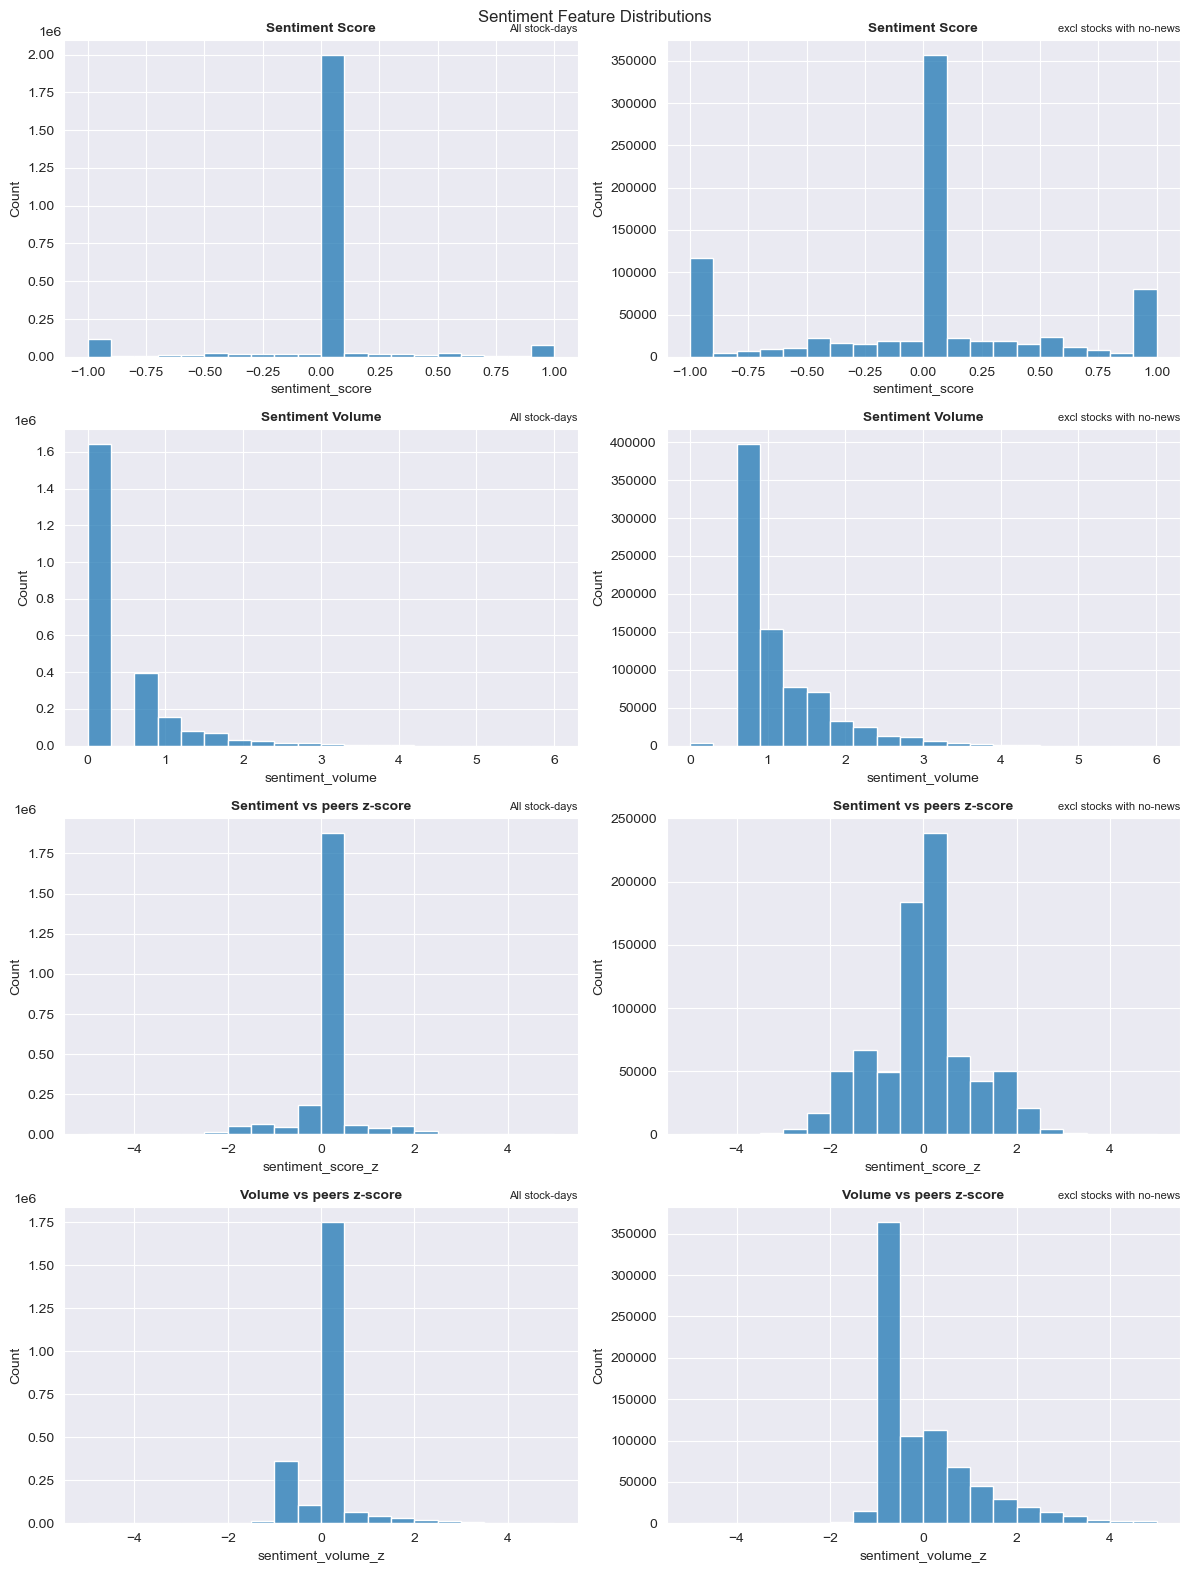

In [18]:
BINS = 20
fig, axes = plt.subplots(4, 2, figsize=(12, 16), sharey=False)

covered = daily[daily['story_count'] > 0]

sns.histplot(data=daily, x='sentiment_score', bins=BINS, ax=axes[0, 0])
axes[0, 0].set_title('All stock-days',loc='right',fontsize=8)
axes[0, 0].yaxis.get_offset_text().set_position((-0.05, 1))

sns.histplot(data=covered, x='sentiment_score', bins=BINS, ax=axes[0, 1])
axes[0, 1].set_title('excl stocks with no-news',loc='right',fontsize=8)

sns.histplot(data=daily, x='sentiment_volume', bins=BINS, ax=axes[1, 0])
axes[1, 0].set_title('All stock-days',loc='right',fontsize=8)
axes[1, 0].yaxis.get_offset_text().set_position((-0.1, 1))

sns.histplot(data=covered, x='sentiment_volume', bins=BINS, ax=axes[1, 1])
axes[1, 1].set_title('excl stocks with no-news',loc='right',fontsize=8)

sns.histplot(data=daily, x='sentiment_score_z', bins=BINS, ax=axes[2, 0])
axes[2, 0].set_title('All stock-days',loc='right',fontsize=8)
axes[2, 0].yaxis.get_offset_text().set_position((-0.1, 1))

sns.histplot(data=covered, x='sentiment_score_z', bins=BINS, ax=axes[2, 1])
axes[2, 1].set_title('excl stocks with no-news',loc='right',fontsize=8)

sns.histplot(data=daily, x='sentiment_volume_z', bins=BINS, ax=axes[3, 0])
axes[3, 0].set_title('All stock-days',loc='right',fontsize=8)
axes[3, 0].yaxis.get_offset_text().set_position((-0.1, 1))

sns.histplot(data=covered, x='sentiment_volume_z', bins=BINS, ax=axes[3, 1])
axes[3, 1].set_title('excl stocks with no-news',loc='right',fontsize=8)

row_titles = ['Sentiment Score','Sentiment Volume','Sentiment vs peers z-score','Volume vs peers z-score']
for row,title in enumerate(row_titles):
    axes[row, 0].set_title(title, loc='center', fontsize=10, fontweight='bold')
    axes[row, 1].set_title(title, loc='center', fontsize=10, fontweight='bold')
plt.suptitle('Sentiment Feature Distributions')
plt.tight_layout()
plt.show()



In [73]:
sdf.dtypes

StoryID                                         object
Timestamp_utc                      datetime64[ns, UTC]
Ticker                                          object
Country                                         object
ISIN                                            object
Sentiment                                        int64
Confidence                                     float64
Novelty                                          int64
Topic                                           object
Relevance                                      float64
HeadlineOnly                                    object
AutoMessage                                     object
Source                                          object
MarketImpactScore                              float64
Prob_POS                                       float64
Prob_NTR                                       float64
Prob_NEG                                       float64
Timestamp             datetime64[ns, America/New_York]
trading_da

In [21]:
capped = ((daily['sentiment_score_z'].abs() == 5.0).sum(),
          (daily['sentiment_volume_z'].abs() == 5.0).sum())
print(f'Capped at ±5 — score: {capped[0]:,}  volume: {capped[1]:,}')

Capped at ±5 — score: 687  volume: 1,766


In [22]:
#Generate a global / Universe sentiment score for each day. Remember to groupby 'trading_day' only.
sdf['weight'] = sdf['Relevance'] * sdf['Confidence']
sdf['weighted_sentiment'] = sdf['weight'] * sdf['Sentiment']
sdf['is_new_story'] = (sdf['Novelty'] == 1).astype('int8')

# 3. Aggregate to one row per (trading_day)
agg = (
    sdf.groupby(['trading_day'], sort=False)
       .agg(
            weighted_sentiment_sum=('weighted_sentiment', 'sum'),
            weight_sum=('weight', 'sum'),
            new_story_count=('is_new_story', 'sum'),
            universe_story_count=('Sentiment','size'),
       )
       .reset_index()
)

# Weighted mean sentiment, with a guard for the case where stories exist
# but every weight is zero (all-tied probabilities -> Confidence == 0).
agg['universe_sentiment_score'] = np.where(
    agg['weight_sum'] > 0,
    agg['weighted_sentiment_sum'] / agg['weight_sum'],
    0.0,
)

# Volume of new coverage, log-compressed.
agg['universe_sentiment_volume'] = np.log1p(agg['new_story_count'])

#Drop the construction columns.
agg = agg.drop(columns=['weighted_sentiment_sum', 'weight_sum',
                        'new_story_count'])

In [107]:
universe_isins = set(ust['ISIN'])          # your 1,932-stock universe, from the tickers file
sdf_isins = set(sdf['ISIN'].unique())

outside_universe = sdf_isins - universe_isins
print(f"ISINs in sdf but NOT in your universe: {len(outside_universe)}")

ISINs in sdf but NOT in your universe: 0


In [23]:
print(agg.shape)          # expect ~ number of distinct dates with news, likely close to your trading-day count
print(agg['trading_day'].is_unique)   # should be True

(1884, 4)
True


In [24]:
print(agg['universe_sentiment_score'].describe())
print(agg['universe_sentiment_volume'].describe())

count    1884.000000
mean       -0.004828
std         0.083270
min        -0.446055
25%        -0.055720
50%         0.000472
75%         0.048735
max         0.733171
Name: universe_sentiment_score, dtype: float64
count    1884.000000
mean        7.113386
std         0.294820
min         5.783825
25%         6.912494
50%         7.106606
75%         7.313220
max         8.165932
Name: universe_sentiment_volume, dtype: float64


In [25]:
agg['universe_sentiment_volume'].isna().sum()

np.int64(0)

In [26]:
skeleton_days = set(daily['trading_day'].unique())
universe_days = set(agg['trading_day'].unique())

print(f"Trading days in skeleton but not in universe agg: {len(skeleton_days - universe_days)}")
print(f"Days in universe agg but not in skeleton: {len(universe_days - skeleton_days)}")

Trading days in skeleton but not in universe agg: 37
Days in universe agg but not in skeleton: 0


In [121]:
print('Skeleton date range :', daily['trading_day'].min(), daily['trading_day'].max())
print('Universe date range :', agg['trading_day'].min(), agg['trading_day'].max())

Skeleton date range : 2017-12-04 00:00:00 2025-07-28 00:00:00
Universe date range : 2018-01-02 00:00:00 2025-07-01 00:00:00


In [27]:
missing_days = sorted(skeleton_days - universe_days)

# Split out the deliberate buffer days from anything genuinely unexplained
buffer_start = missing_days_before = [d for d in missing_days if d < pd.Timestamp('2018-01-02')]
buffer_end = [d for d in missing_days if d > pd.Timestamp('2025-07-01')]
unexplained = [d for d in missing_days if pd.Timestamp('2018-01-02') <= d <= pd.Timestamp('2025-07-01')]

print(f'Buffer days before range : {len(buffer_start)}')
print(f'Buffer days after range  : {len(buffer_end)}')
print(f'Unexplained (inside the universe date range!) : {len(unexplained)}')

if unexplained:
    print(pd.Series(unexplained).dt.year.value_counts().sort_index())
    print(unexplained[:10])

Buffer days before range : 19
Buffer days after range  : 18
Unexplained (inside the universe date range!) : 0


In [19]:
# 1. Confirm no weekend rows remain anywhere in the corrected skeleton
print(daily['trading_day'].dt.dayofweek.value_counts().sort_index())

# 2. Re-run the earlier gap check — the 854 "unexplained" gap should have
#    collapsed down to roughly just your ~56-day buffer now
skeleton_days = set(daily['trading_day'].unique())
universe_days = set(agg['trading_day'].unique())
print(len(skeleton_days - universe_days))

trading_day
0    453592
1    501811
2    496960
3    491971
4    489420
Name: count, dtype: int64
37


In [32]:
print(len(daily))
daily = daily.merge(agg, on='trading_day', how='left')
print(len(daily))

2433754
2433754


In [ ]:
#Identify any of the missing sentiment fields in the univseral sentiment fields.
#Print out the dates...fix and then print again....

missing = daily[daily['universe_sentiment_score'].isna()]
print('Before....')
print(missing['trading_day'].unique())
print(missing['trading_day'].min(), missing['trading_day'].max())

daily[['universe_sentiment_score', 'universe_sentiment_volume']] = \
    daily[['universe_sentiment_score', 'universe_sentiment_volume']].fillna(0.0)

print('After....')
print(missing['trading_day'].unique())
print(missing['trading_day'].min(), missing['trading_day'].max())



In [34]:
daily.to_parquet(DAILY_SENTIMENT, index=False)
print('Saved sentiment_daily.parquet')
print('____________________________________________________________')
print(daily.columns)
print('____________________________________________________________')
daily.head(5)

Saved sentiment_daily.parquet
____________________________________________________________
Index(['ISIN', 'trading_day', 'Sector', 'sentiment_score', 'sentiment_volume',
       'sentiment_score_z', 'sentiment_volume_z', 'story_count',
       'universe_story_count', 'universe_sentiment_score',
       'universe_sentiment_volume'],
      dtype='object')
____________________________________________________________


,ISIN,trading_day,Sector,sentiment_score,sentiment_volume,sentiment_score_z,sentiment_volume_z,story_count,universe_story_count,universe_sentiment_score,universe_sentiment_volume
0,US8110544025,2017-12-08,Consumer Discretionary,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,US8110544025,2017-12-11,Consumer Discretionary,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,US8110544025,2017-12-12,Consumer Discretionary,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,US8110544025,2017-12-13,Consumer Discretionary,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,US8110544025,2017-12-14,Consumer Discretionary,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
